# Exploratory Data Analysis - Scoring Companies Dataset
This notebook explores `scoring_companies.csv` and compares its distribution with the training set.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')


## Loading the Dataset


In [2]:
df_scoring = pd.read_csv('../data/scoring_companies.csv')
df_train = pd.read_csv('../data/train_companies.csv')
print(f'Scoring dataset shape: {df_scoring.shape}')
df_scoring.head()


Scoring dataset shape: (50, 13)


,company_id,company_name,sector,country,revenue_m,ebitda_margin,debt_ratio,interest_coverage,cash_ratio,years_in_operation,employee_count,revenue_growth,business_description
0,1001,Aster Holdings #0001,Manufacturing,Netherlands,67.516071,0.252598,0.440629,1.683539,0.150852,5,156,0.021782,Aster Holdings #0001 operates in the manufactu...
1,1002,BluePeak Solutions #0002,Logistics,France,10.607306,0.137340,0.552999,4.214265,0.049301,10,158,0.101211,BluePeak Solutions #0002 operates in the logis...
2,1003,Crestline Partners #0003,Consumer Finance,Netherlands,37.615011,0.222036,0.489677,4.046510,0.097710,9,143,0.046904,Crestline Partners #0003 operates in the consu...
3,1004,Dune Finance #0004,Hospitality,Luxembourg,37.101790,0.179071,0.674781,2.609481,0.093720,4,145,0.006581,Dune Finance #0004 operates in the hospitality...
4,1005,Evergreen Holdings #0005,Consumer Finance,Germany,42.603768,0.159156,0.721071,2.286937,0.066982,12,124,-0.109049,Evergreen Holdings #0005 operates in the consu...


## Data Quality & Missing Values


In [3]:
df_scoring.info()
missing = df_scoring.isnull().sum()
print('\nMissing values per column:')
print(missing[missing > 0] if missing.any() else 'No missing values.')


<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   company_id            50 non-null     int64  
 1   company_name          50 non-null     str    
 2   sector                50 non-null     str    
 3   country               50 non-null     str    
 4   revenue_m             50 non-null     float64
 5   ebitda_margin         50 non-null     float64
 6   debt_ratio            50 non-null     float64
 7   interest_coverage     50 non-null     float64
 8   cash_ratio            50 non-null     float64
 9   years_in_operation    50 non-null     int64  
 10  employee_count        50 non-null     int64  
 11  revenue_growth        50 non-null     float64
 12  business_description  50 non-null     str    
dtypes: float64(6), int64(3), str(4)
memory usage: 21.0 KB

Missing values per column:
No missing values.


## Comparing Numeric Distributions (Train vs Scoring)
We check if there is any distribution drift between the training set and the scoring set.


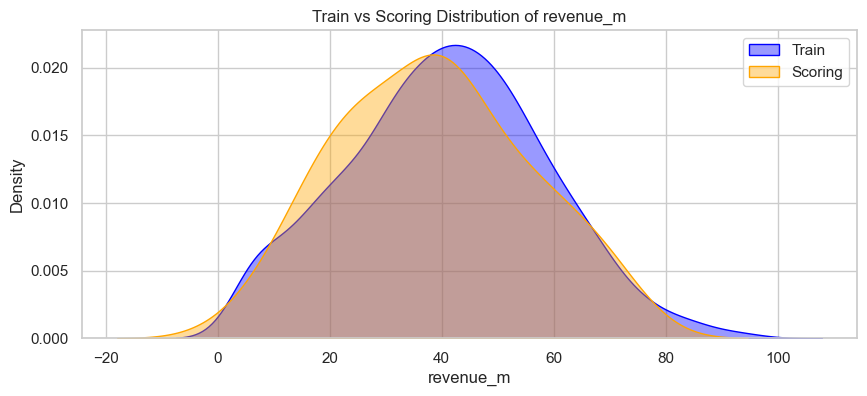

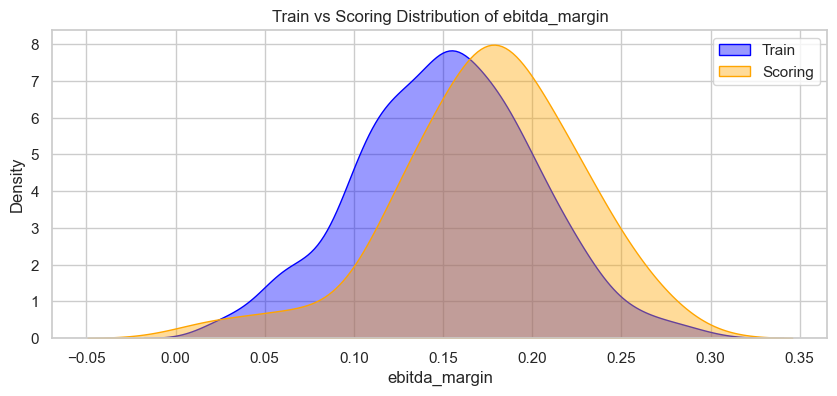

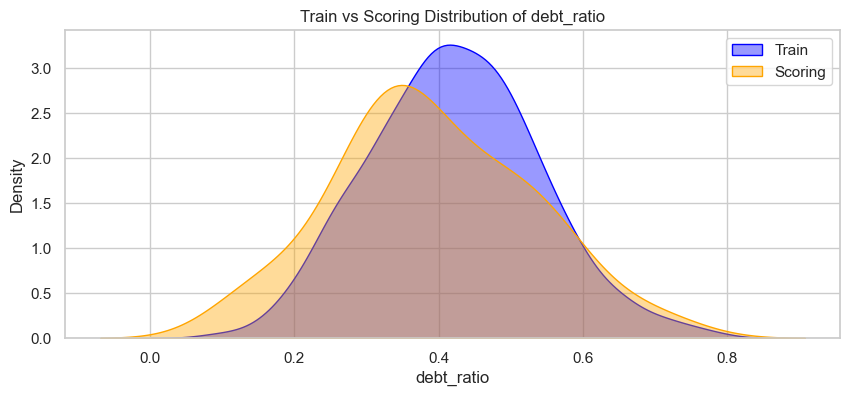

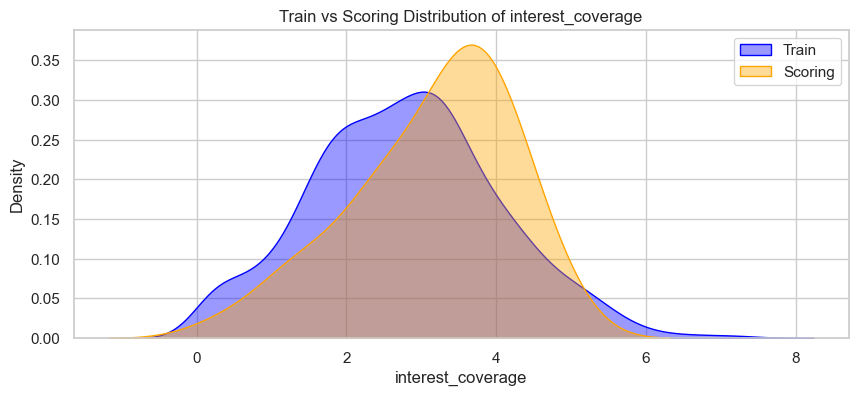

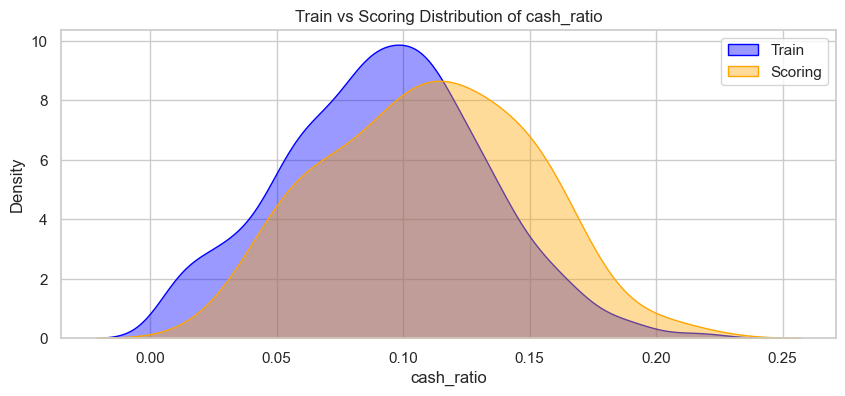

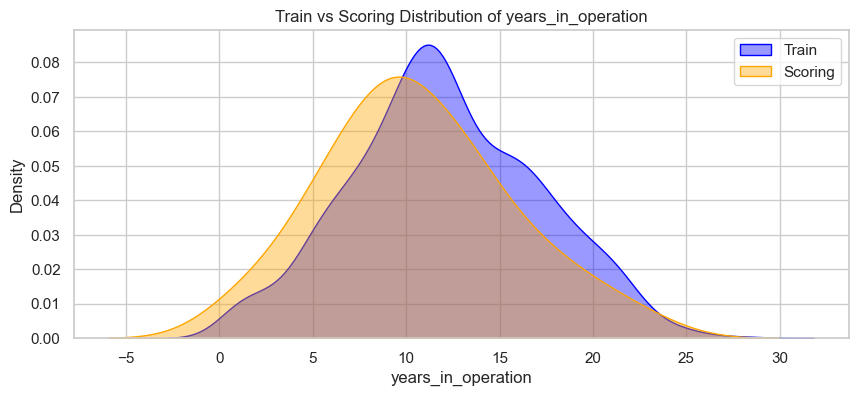

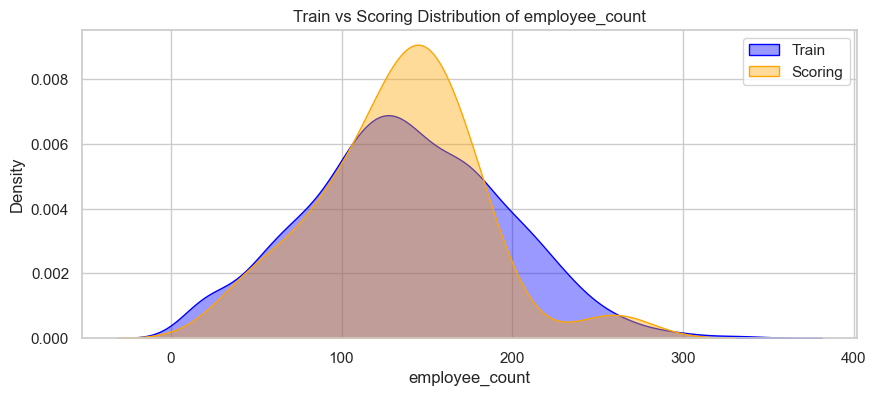

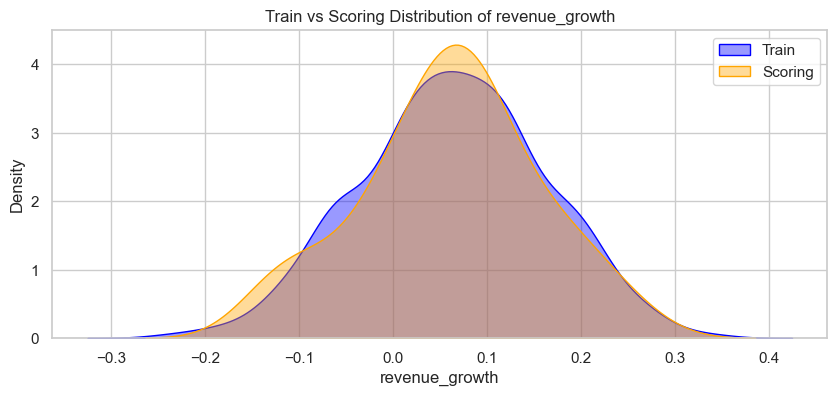

In [4]:
num_cols = df_scoring.select_dtypes(include=[np.number]).columns.tolist()
if 'company_id' in num_cols: num_cols.remove('company_id')

for col in num_cols:
    plt.figure(figsize=(10, 4))
    sns.kdeplot(df_train[col], label='Train', fill=True, alpha=0.4, color='blue')
    sns.kdeplot(df_scoring[col], label='Scoring', fill=True, alpha=0.4, color='orange')
    plt.title(f'Train vs Scoring Distribution of {col}')
    plt.legend()
    plt.show()


## Comparing Categorical Distributions


C:\Users\pedre\AppData\Local\Temp\ipykernel_22604\1793746192.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, y=col, ax=axes[0], order=df_train[col].value_counts().index, palette='Blues_r')
C:\Users\pedre\AppData\Local\Temp\ipykernel_22604\1793746192.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_scoring, y=col, ax=axes[1], order=df_scoring[col].value_counts().index, palette='Oranges_r')


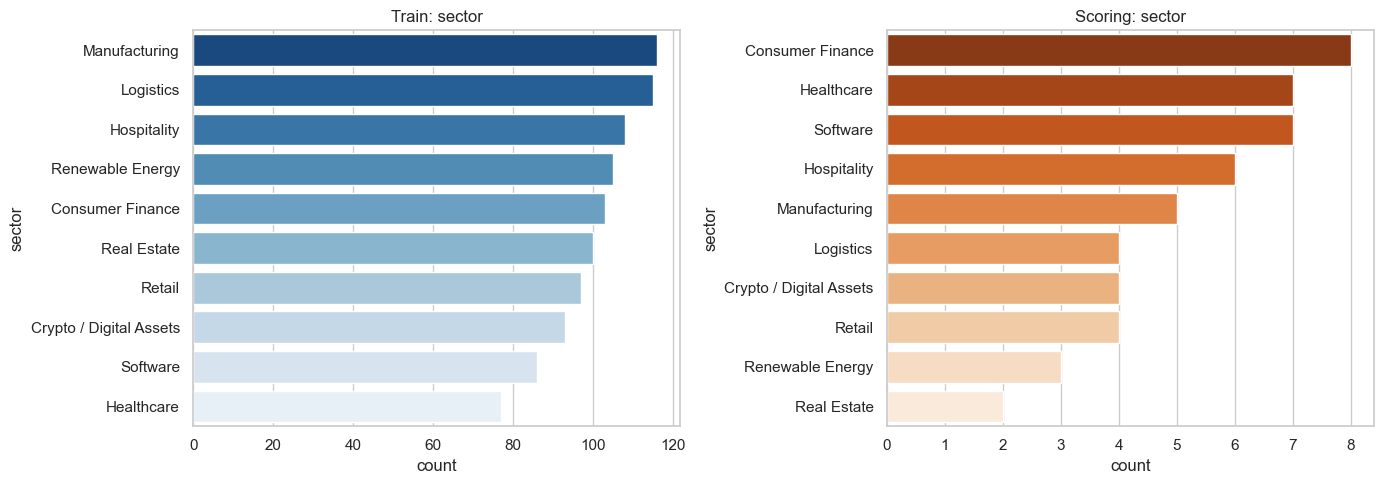

C:\Users\pedre\AppData\Local\Temp\ipykernel_22604\1793746192.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, y=col, ax=axes[0], order=df_train[col].value_counts().index, palette='Blues_r')
C:\Users\pedre\AppData\Local\Temp\ipykernel_22604\1793746192.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_scoring, y=col, ax=axes[1], order=df_scoring[col].value_counts().index, palette='Oranges_r')


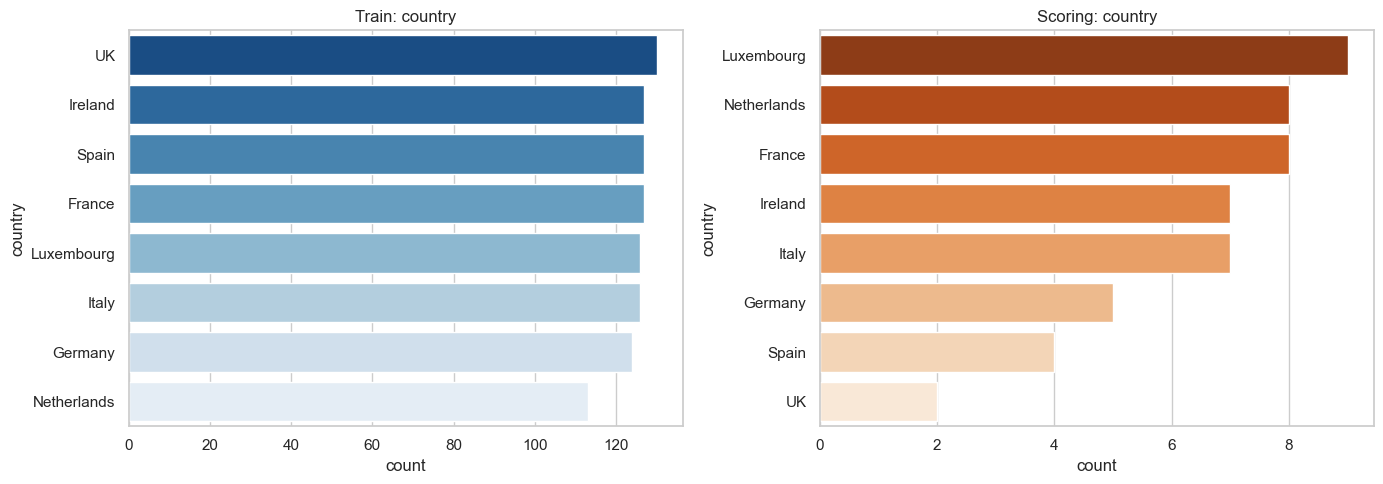

In [5]:
for col in ['sector', 'country']:
    if col in df_scoring.columns:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        sns.countplot(data=df_train, y=col, ax=axes[0], order=df_train[col].value_counts().index, palette='Blues_r')
        axes[0].set_title(f'Train: {col}')
        sns.countplot(data=df_scoring, y=col, ax=axes[1], order=df_scoring[col].value_counts().index, palette='Oranges_r')
        axes[1].set_title(f'Scoring: {col}')
        plt.tight_layout()
        plt.show()
